# VMD-MFGNN — Robustness Experiments, Colab Runner

This notebook closes 5 identified gaps in Paper 1 (VMD-MFGNN) before final
submission, all stress-testing the central "Adjacency Collapse" finding
(see `STATUS.md`, "Adjacency Collapse Diagnosed", 2026-08-09): does the
graph-embedding collapse depend on VMD's band count K, the decomposition
method, the training loss function, or the random seed -- or is it
invariant across all of them?

**What this notebook is NOT.** It does not modify, re-run, or risk the
existing, already-verified main pipeline (`results/`,
`notebooks/archive_paper1_vmd_mfgnn/vmd_mfgnn_v2_colab.ipynb`). All new
results go to `results/robustness/<experiment>/`, entirely separate
directories. All new code (`src/data_pipeline.py`'s `EMDDecomposer`/
`CEEMDANDecomposer`/`build_decomposed_modes`, `src/trainer.py`'s
`training.loss_fn` option, `src/hpo.py`'s widened search space,
`src/diagnostics.py`, `src/experiments.py`) is backward compatible: every
new option defaults to the existing, already-verified behavior when not
explicitly invoked (same pattern as `no_decay_graph_embeddings`/
`normalize_graph_embeddings` in `configs/default.yaml`).

**Sections:**
1. Setup (Drive mount, repo clone/pull, dependency install)
2. Data acquisition (reuse `data_pipeline.py`, shape/range sanity checks)
3. Experiment 1 -- VMD band-count (K) sweep, K in {3,5,7,9}
4. Experiment 2 -- Decomposition method comparison (VMD vs EMD, optional CEEMDAN)
5. Experiment 3 -- Loss function comparison (MSE vs MAE vs Huber)
6. Experiment 4 -- Multi-seed robustness (full_model vs pooled_graph_matched_dim, 5 seeds)
7. Experiment 5 -- Wider HPO pass (K + weight_decay + batch_size added, 30 trials)
8. Final aggregation: does the collapse finding depend on K / decomposition / loss / seed?
9. Package results for download

**Resumability design (read before running Section 3 onward).** Every
experiment cell (one K value, one decomposition method, one loss function,
one (variant, seed) pair) is appended as ONE line to its own
`results/robustness/<exp>/*_results.jsonl` file IMMEDIATELY after it finishes
(`src/experiments.py`'s `run_resumable_grid`/`append_cell_result`), and is
then **synced to Drive immediately as well**, per cell -- jsonl row,
checkpoint, and raw prediction `.npy` together (the `on_cell_done` callback,
built by `make_cell_sync` in the shared-helpers cell below). Per-cell rather
than per-section matters: Section 6's multiseed grid is 10 cells x ~30 min,
so syncing only when the whole grid returns would leave up to ~6 hours of
finished training on the ephemeral Colab VM disk, to be wiped by a single
disconnect. That is exactly the failure documented in
`docs/cubench_colab_resume_incident.md` (artifacts that only ever lived on
the VM), one layer up from where it was found the first time.

On restart, a cell counts as done ONLY if its jsonl row exists AND its
checkpoint file genuinely exists on disk AND that checkpoint's
`completed=True` flag is set -- matching this project's own documented fix
for the equivalent bug in CuBench (`paper2/notebooks/cubench_colab.ipynb`;
see git log "Fix resume logic to require actual prediction files, not just
log lines"). Drive sync **unconditionally overwrites** (no size/mtime "is
this newer" heuristic) -- deliberately avoiding the exact file-size-based
staleness bug class documented in `STATUS.md`/`docs/todo.txt` item 5.

`data/` (raw prices + every decomposed-modes cache) is synced to Drive too,
under `Copper_Paper1/data_cache/`. It is git-ignored, so without this a
fresh runtime would re-download from yfinance and re-run a ~30-40 min
decomposition per (method, K) every session -- and, worse, a revised
yfinance pull would change the price-array hash `build_decomposed_modes`
keys its cache on, silently invalidating every restored cache and training
later sessions on different data than earlier ones.

**One failing cell does not stop the run.** If a single training raises (OOM,
a NaN loss, a transient Colab hiccup), `run_resumable_grid` logs it with a
full traceback, writes NO jsonl row for it (so it is retried on the next
run), and moves on to the next cell -- instead of aborting the section and,
in a Colab "Run All", every subsequent cell with it. A summary of skipped
cells is printed at the end of each grid.

**Section 7's Optuna study is resumable too**, via a SQLite study database
inside `results/robustness/wider_hpo/` that is synced to Drive after every
trial. `n_trials=30` is a TARGET TOTAL on resume, not "30 more".

**Honesty note on wall-clock estimates.** Every section below states a
realistic estimate reasoned from this project's own logged timing (the main
notebook's one completed real run: `VMD-MFGNN training done in 1944.9s`
(~32 min) at `hidden_dim=128`; the graph-fix notebook's estimates built on
that same number; CuBench's logged per-family throughput). These are
planning numbers, not guarantees -- this notebook was built without GPU
access in the packaging environment, so none of Sections 3-7 have actually
been run end-to-end. Verification that WAS possible locally (CPU-only, no
GPU) is documented inline in Section 1 and in the task report.


## Section 1: Setup

**Realistic wall-clock estimate: 5-15 minutes** (network-bound: Drive mount,
git clone, `pip install`). Same order of magnitude as the main notebook's
Setup section.


### 1.1 Mount Google Drive (content-addressed sync, no size-based staleness check)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = '/content/drive/MyDrive/Copper_Paper1'
os.makedirs(DRIVE_ROOT, exist_ok=True)
print('Drive results root:', DRIVE_ROOT)


Mounted at /content/drive
Drive results root: /content/drive/MyDrive/Copper_Paper1


### 1.2 Get the repo

**IMPORTANT:** this notebook's new code (`src/experiments.py`,
`src/diagnostics.py`, the `EMDDecomposer`/loss-function/wider-HPO additions
to `src/data_pipeline.py`/`src/trainer.py`/`src/hpo.py`) must be **pushed to
the remote** (`https://github.com/anmol0705/Copper_Price_Forecasting`,
branch `graph-fix-experiment` as of this writing -- confirm with
`git branch --show-current` / `git log -1` locally before relying on a
fresh clone here) before this cell will see it. If you're running this right
after the code was written locally and haven't pushed yet, push first, or
use Option B (zip upload) instead.


In [3]:


# ---- OPTION A: git clone/pull from the real remote (recommended) ----
REPO_URL = 'https://github.com/anmol0705/Copper_Price_Forecasting.git'
BRANCH = 'graph-fix-experiment'  # confirm this is still current: `git branch --show-current` locally

import os, subprocess
if not os.path.exists('/content/copper'):
    subprocess.run(['git', 'clone', '--branch', BRANCH, REPO_URL, '/content/copper'], check=True)
else:
    subprocess.run(['git', '-C', '/content/copper', 'fetch', 'origin', BRANCH], check=True)
    subprocess.run(['git', '-C', '/content/copper', 'checkout', BRANCH], check=True)
    subprocess.run(['git', '-C', '/content/copper', 'reset', '--hard', f'origin/{BRANCH}'], check=True)
print('Repo ready at /content/copper on branch', BRANCH)


Repo ready at /content/copper on branch graph-fix-experiment


In [4]:
# ---- OPTION B: upload a copper.zip (use if you haven't pushed yet) ----
# 1. Zip the repo locally: `cd D:\copper && zip -r copper.zip . -x '.git/*'`
# 2. Run this cell, click "Choose Files", select copper.zip.
# 3. Uncomment the extraction lines.

# from google.colab import files
# uploaded = files.upload()  # select copper.zip
# import zipfile
# with zipfile.ZipFile('copper.zip', 'r') as zf:
#     zf.extractall('/content/copper')
# print('Extracted to /content/copper')


In [5]:
import os, sys
assert os.path.isdir('/content/copper'), (
    "Repo not found at /content/copper -- run Option A or Option B above first."
)
os.chdir('/content/copper/paper1')  # all paths below (data/, results/, configs/) are relative to paper1/
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print('cwd:', os.getcwd())
print(sorted(os.listdir('.')))


cwd: /content/copper/paper1
['configs', 'latest_results', 'literature', 'manuscript', 'notebooks', 'requirements.txt', 'results', 'scripts', 'src', 'tests']


### 1.3 Install dependencies

In [6]:
!pip install -q -r requirements.txt
!pip install -q vmdpy optuna yfinance torch-geometric EMD-signal


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.3 MB/s eta 0:00:00


### 1.4 Confirm runtime, sanity-import the new modules

In [7]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('WARNING: no GPU detected -- Colab Runtime > Change runtime type > GPU. '
          'CPU-only will still run correctly, just much slower for the K-sweep/'
          'decomposition/loss/multiseed experiments (item 5, wider HPO, is the '
          'most CPU-sensitive since it runs many short trials).')

from src.utils import load_config
from src.data_pipeline import create_datasets, EMDDecomposer, CEEMDANDecomposer
from src.trainer import VMDMFGNNTrainer
from src.diagnostics import run_full_diagnostic
from src import experiments as exp
from src import hpo as hpo_mod
print('All new modules import cleanly.')


CUDA available: True
GPU: Tesla T4
All new modules import cleanly.


## Shared Drive-sync + progress-checker helpers

Same pattern as `paper2/notebooks/cubench_colab.ipynb`, with two deliberate
upgrades: unconditional overwrite (no size/mtime staleness heuristic -- see
Section-1 note), and **per-cell** rather than per-family sync cadence.
CuBench synced per model family because it had 2,838 tiny cells and per-cell
Drive I/O would have dominated; here the grids are 4/2/3/10 cells of ~30 min
each, so a per-cell Drive copy is free next to the training it protects.

Synced per completed cell: the experiment's `*_results.jsonl`, its
`checkpoints/`, its raw prediction `.npy` files, AND any decomposition cache
newly built under `data/`.


In [8]:
import shutil, time as _time

# `data/` (raw_prices.csv + every decomposed-modes .npy cache) is deliberately
# NOT under results/, and it is git-ignored -- so on a fresh Colab session it
# would otherwise be rebuilt from scratch every single time: a fresh yfinance
# download plus ~30-40 min of CPU per (method, K) decomposition. Backing it up
# to Drive turns that into a copy, and -- more importantly than the time -- it
# PINS the exact price array across sessions. build_decomposed_modes keys its
# cache on a sha256 of the price array, so if a later yfinance pull revised or
# backfilled even one row, every restored modes cache would silently invalidate
# AND session 2's models would be trained on different data than session 1's.
DRIVE_DATA_DIR = os.path.join(DRIVE_ROOT, 'data_cache')


def sync_to_drive(local_dir, note=''):
    """Unconditionally copies `local_dir` (a results/robustness/<exp> dir,
    containing both the *_results.jsonl and its checkpoints/ + predictions/
    subdirs) to the matching path under DRIVE_ROOT. Always overwrites --
    deliberately no size/mtime freshness check (see Section 1's staleness-bug
    note)."""
    if not os.path.isdir(local_dir):
        print(f'{local_dir} does not exist yet, nothing to sync')
        return
    rel = os.path.relpath(local_dir, 'results')
    dest = os.path.join(DRIVE_ROOT, rel)
    os.makedirs(os.path.dirname(dest) or '.', exist_ok=True)
    shutil.copytree(local_dir, dest, dirs_exist_ok=True)
    print(f'[{_time.strftime("%H:%M:%S")}] synced {local_dir} -> {dest} {note}')


def restore_from_drive_if_present(local_dir):
    """Opposite direction: pulls a prior Drive-backed copy down into the
    fresh clone's local_dir, if one exists, so a resumed session picks up
    completed cells from before a disconnect. Always overwrites local with
    the Drive copy -- same no-staleness-heuristic principle."""
    rel = os.path.relpath(local_dir, 'results')
    src = os.path.join(DRIVE_ROOT, rel)
    if os.path.isdir(src):
        os.makedirs(local_dir, exist_ok=True)
        shutil.copytree(src, local_dir, dirs_exist_ok=True)
        print(f'Restored {src} -> {local_dir}')
    else:
        print(f'No prior Drive backup at {src}, starting fresh')


def sync_data_cache_to_drive(note=''):
    """Backs up data/ (raw_prices.csv + *_modes*.npy + their _meta.json
    sidecars) to Drive. NOTE: this deliberately does NOT go through
    sync_to_drive() -- that helper computes os.path.relpath(local_dir,
    'results'), which for 'data' yields '../data' and would write OUTSIDE
    DRIVE_ROOT. Separate helper, separate Drive subdirectory."""
    if not os.path.isdir('data'):
        print('no data/ yet, nothing to sync')
        return
    os.makedirs(DRIVE_DATA_DIR, exist_ok=True)
    n = 0
    for fname in sorted(os.listdir('data')):
        p = os.path.join('data', fname)
        if os.path.isfile(p):
            shutil.copy2(p, os.path.join(DRIVE_DATA_DIR, fname))
            n += 1
    print(f'[{_time.strftime("%H:%M:%S")}] synced {n} data-cache file(s) -> '
          f'{DRIVE_DATA_DIR} {note}')


def restore_data_cache_from_drive():
    """Restores data/ from Drive on a fresh runtime. Presence-based only
    (copies a Drive file down when the local one is absent) -- these caches
    are write-once, so there is no freshness ambiguity to get wrong, and no
    size/mtime heuristic is used (that heuristic is the exact documented bug
    class from docs/todo.txt item 5)."""
    if not os.path.isdir(DRIVE_DATA_DIR):
        print(f'No prior Drive data cache at {DRIVE_DATA_DIR}, starting fresh '
              f'(expect a fresh yfinance pull + full decomposition cost)')
        return
    os.makedirs('data', exist_ok=True)
    n = 0
    for fname in sorted(os.listdir(DRIVE_DATA_DIR)):
        srcf = os.path.join(DRIVE_DATA_DIR, fname)
        dstf = os.path.join('data', fname)
        if os.path.isfile(srcf) and not os.path.exists(dstf):
            shutil.copy2(srcf, dstf)
            n += 1
    print(f'Restored {n} data-cache file(s) from {DRIVE_DATA_DIR}')


def make_cell_sync(results_dir, label):
    """Builds the `on_cell_done` callback handed to every experiment driver in
    src/experiments.py. It fires after EACH grid cell's jsonl row is flushed to
    local disk, and pushes that cell's results dir (jsonl + checkpoint +
    prediction .npy) AND any newly-built decomposition cache to Drive right
    then.

    This is the difference between losing one in-flight cell and losing every
    completed-but-unsynced cell when Colab disconnects. Syncing only after the
    whole grid returns -- as this notebook originally did -- means Section 6's
    ~3.5-7 hour, 10-cell multiseed grid keeps ALL of its output on the
    ephemeral VM disk until the very end; a disconnect at hour 6 wipes nine
    finished trainings. That is the same failure mode as
    docs/cubench_colab_resume_incident.md (artifacts that only ever lived on
    the Colab VM), one layer up.

    Per-cell (rather than CuBench's per-family) cadence is right here: these
    grids have 4/2/3/10 cells at ~30 min each, so the Drive copy is negligible
    next to the training it protects -- unlike CuBench's 2,838 tiny cells.
    """
    def _on_cell_done(cell_key, result):
        sync_to_drive(results_dir, note=f'after {label} cell {tuple(cell_key)}')
        sync_data_cache_to_drive(note=f'after {label} cell {tuple(cell_key)}')
    return _on_cell_done


def jsonl_progress(jsonl_path):
    import json as _json
    if not os.path.exists(jsonl_path):
        print(f'{jsonl_path}: no results yet.')
        return {}
    seen, errors = {}, 0
    with open(jsonl_path) as f:
        for line in f:
            try:
                r = _json.loads(line)
            except Exception:
                continue
            key = tuple(r.get('cell_key', []))
            seen[key] = r
            if 'error' in r:
                errors += 1
    print(f'{jsonl_path}: {len(seen)} completed cells (errored: {errors})')
    for k in sorted(seen):
        print('  ', k)
    return seen


def load_rows_from_jsonl(jsonl_path):
    """Reads ALL rows from a *_results.jsonl file directly off disk (via
    exp.load_completed_cells, with the SAME completed-checkpoint artifact
    check every experiment uses), independent of whatever is or isn't still
    in this kernel's memory. Section 8 uses this (not the in-memory
    k_sweep_results/decomposition_results/etc. variables) specifically so
    the final aggregation works even if you're resuming a fresh kernel
    session and only want to view already-completed results, without
    re-running every Section 3-7 cell first."""
    completed = exp.load_completed_cells(
        jsonl_path, artifact_check_fn=lambda row: exp._checkpoint_is_complete(
            row.get('checkpoint_path', '')))
    return list(completed.values())


## Section 2: Data Acquisition

Reuses `src/data_pipeline.py` unchanged for the base VMD (K=5) dataset --
this is the SAME data build the main pipeline already used and verified,
not a new data path. Per-experiment K/decomposition-method variants each
get their OWN cache file (`data/vmd_modes_K{K}.npy`,
`data/{method}_modes_K{K}.npy`) and are built lazily inside Sections 3-4,
not here.

**Realistic wall-clock estimate: 1-3 min (warm cache, e.g. restored from
Drive) or 15-45 min (cold, per the main notebook's documented VMD
decomposition timing).**


In [9]:
# Restore any Drive-backed data cache FIRST (raw_prices.csv + decomposed-modes
# caches). On a fresh Colab runtime this is what makes Section 2 take ~1 min
# instead of re-downloading from yfinance and re-running a ~30-40 min VMD
# decomposition, and it pins the exact price array across sessions so a later
# yfinance revision can't silently invalidate every cached decomposition
# mid-experiment.
restore_data_cache_from_drive()

config = load_config('configs/default.yaml')
print('Base config vmd.K:', config['vmd']['K'])
print('Base config training.loss_fn:', config['training'].get('loss_fn', 'mse (default)'))

base_data = create_datasets(config)
print(f"Variables: {base_data['variable_names']}")
print(f"Train/Val/Test samples: {len(base_data['train_ds'])}/{len(base_data['val_ds'])}/{len(base_data['test_ds'])}")
print(f"num_vars={base_data['num_vars']}, num_modes={base_data['num_modes']}")

sync_data_cache_to_drive(note='after base K=5 data build')

# Shape/range sanity check against the known-good original run (see STATUS.md /
# results/archive_paper1/all_results.json for the reference scale): 8 variables,
# K=5 modes, ~4000 trading days total.
# NOTE (hard stop, by design): if yfinance drops another ticker the way it
# already dropped zinc/nickel, this assertion halts the notebook and needs a
# human. That is deliberate fail-fast behavior -- do not "fix" it by relaxing
# the assertion; investigate which ticker went missing.
assert base_data['num_vars'] == 8, f"expected 8 variables, got {base_data['num_vars']}"
assert base_data['num_modes'] == config['vmd']['K']
x0, y0 = base_data['train_ds'][0]
print('Sample X shape:', tuple(x0.shape), 'Y shape:', tuple(y0.shape))
assert x0.shape == (config['data']['lookback'], config['vmd']['K'], base_data['num_vars'])
print('Shape checks passed.')


Restored 11 data-cache file(s) from /content/drive/MyDrive/Copper_Paper1/data_cache
Base config vmd.K: 5
Base config training.loss_fn: mse
Variables: ['copper', 'aluminum', 'gold', 'oil', 'dxy', 'sp500', 'vix', 'us10y']
Train/Val/Test samples: 1343/505/984
num_vars=8, num_modes=5
[15:59:55] synced 11 data-cache file(s) -> /content/drive/MyDrive/Copper_Paper1/data_cache after base K=5 data build
Sample X shape: (60, 5, 8) Y shape: (4,)
Shape checks passed.


## Section 3: Experiment 1 — VMD Band-Count (K) Sweep

Retrains full VMD-MFGNN at K in {3, 5, 7, 9}, using the already-tuned other
hyperparameters (`results/archive_paper1/hpo_best_params.json`), and runs
the SAME gradient/adjacency diagnostic used to find the original bug
(`src/diagnostics.py::run_full_diagnostic`, reusing STATUS.md's exact
methodology: RMS embedding magnitude vs. Xavier-init reference, softmax
spread, fraction of kept edges within tolerance of 1/N, real
forward/backward gradient norms on emb1/emb2, and embedding-direction
cosine similarity vs. a fresh init). Directly tests whether the collapse is
K-dependent or invariant.

**Resumable:** each K is one jsonl cell (own checkpoint + own VMD-modes
cache), so a disconnect resumes at the next incomplete K.

**Realistic wall-clock estimate:** ~30-40 min one-time CPU cost per NEW K's
VMD decomposition (per `VMDDecomposer`'s docstring: "~30-40 minutes one-time
CPU for the full ~4,000-day x 10-variable dataset" -- unaffected by the
2026-08-07 8-variable scope reduction) + ~20-40 min training per K (per the
main notebook's ~32 min real observed run) + <1 min diagnostic. **4 K
values x (~35 min decomposition + ~30 min training) = roughly 4-4.5 hours**
if all 4 K-value caches are cold; **~2 hours** if K=5's cache can be reused
from the main pipeline's `data/vmd_modes.npy` (only 3 NEW decompositions
needed, K=3/7/9). Budget for at least one disconnect; resume picks up at
the next incomplete K.


In [ ]:
K_SWEEP_DIR = 'results/robustness/k_sweep'
restore_from_drive_if_present(K_SWEEP_DIR)
jsonl_progress(f'{K_SWEEP_DIR}/k_sweep_results.jsonl')


Restored /content/drive/MyDrive/Copper_Paper1/robustness/k_sweep -> results/robustness/k_sweep
results/robustness/k_sweep/k_sweep_results.jsonl: 4 completed cells (errored: 0)
   (3,)
   (5,)
   (7,)
   (9,)


{(3,): {'cell_key': [3],
  'K': 3,
  'test_metrics': {'h1': {'rmse': 0.017820599883110695,
    'mae': 0.011962256394326687,
    'mape': 111.19950866699219,
    'r2': 0.004079043865203857,
    'da': 52.03252032520326},
   'h5': {'rmse': 0.03986874414688886,
    'mae': 0.02787729911506176,
    'mape': 113.4241714477539,
    'r2': 0.0007908344268798828,
    'da': 56.19918699186992},
   'h10': {'rmse': 0.055187943476891,
    'mae': 0.03986195847392082,
    'mape': 161.37692260742188,
    'r2': -0.0010913610458374023,
    'da': 52.4390243902439},
   'h22': {'rmse': 0.07793730899283399,
    'mae': 0.060170724987983704,
    'mape': 182.3077850341797,
    'r2': -0.05822861194610596,
    'da': 45.02032520325203},
   'avg_mse': 0.0027567559445742518},
  'diagnostic': {'adjacency_state': {'bands': [{'band': 0,
      'emb1_rms': 0.005229041446000338,
      'emb2_rms': 0.004089312627911568,
      'rms_ratio': 0.016149660440055297,
      'softmax_std': 4.552045083983103e-06,
      'frac_near_uniform

In [ ]:
k_sweep_results = exp.run_k_sweep(
    config, k_values=[3, 5, 7, 9],
    hpo_best_params_path='results/archive_paper1/hpo_best_params.json',
    results_dir=K_SWEEP_DIR,
    on_cell_done=make_cell_sync(K_SWEEP_DIR, 'K-sweep'),
)
sync_to_drive(K_SWEEP_DIR, note='after K-sweep')


[10:03:40] synced results/robustness/k_sweep -> /content/drive/MyDrive/Copper_Paper1/robustness/k_sweep after K-sweep


In [ ]:
# Quick per-K summary: h1 RMSE/MAE/DA + collapse verdict + emb gradient norm.
print(f"{'K':>3} | {'h1_rmse':>9} | {'h1_da':>7} | {'collapse_verdict':<45} | {'emb_grad_norm':>14}")
print('-' * 95)
for row in k_sweep_results:
    k = row['K']
    tm = row['test_metrics']
    diag = row['diagnostic']
    h1 = tm.get('h1', {})
    verdict = diag['adjacency_state']['verdict']
    grad = diag['gradient_magnitude']['emb_grad_norm_mean']
    print(f"{k:>3} | {h1.get('rmse', float('nan')):>9.5f} | {h1.get('da', float('nan')):>6.2f}% | "
          f"{verdict:<45} | {grad:>14.6e}")


  K |   h1_rmse |   h1_da | collapse_verdict                              |  emb_grad_norm
-----------------------------------------------------------------------------------------------
  3 |   0.01782 |  52.03% | COLLAPSED -- all bands show the diagnosed pattern |   3.875052e-18
  5 |   0.01797 |  48.48% | COLLAPSED -- all bands show the diagnosed pattern |   7.121039e-16
  7 |   0.01797 |  50.71% | COLLAPSED -- all bands show the diagnosed pattern |   2.922025e-10
  9 |   0.01879 |  50.71% | COLLAPSED -- all bands show the diagnosed pattern |   8.551562e-14


## Section 4: Experiment 2 — Alternative Decomposition Method Comparison

Retrains full model with VMD replaced by `EMDDecomposer` (item 2), at the
SAME K as the main config (see `EMDDecomposer`'s docstring for exactly how
K interacts with EMD's data-driven natural IMF count: truncate-and-sum the
tail if EMD naturally produces more IMFs than K, zero-pad if fewer -- this
is disclosed, not hidden). Also runs the same gradient/adjacency
diagnostic.

**CEEMDAN (optional, NOT run by default):** implemented
(`CEEMDANDecomposer`), and separately leakage-verified locally at small
scale (`tests/test_emd_leakage.py`'s `CEEMDANDecomposer` check: T=120,
rolling_window=40, trials=5 -- reduced scale for speed, see the timing
notes below). Two REAL bugs were found and fixed during that local
verification, not just theorized:
  1. PyEMD's CEEMDAN defaults to `parallel=True`, spawning a fresh
     `multiprocessing` worker pool PER WINDOW -- on Windows (spawn-based
     process creation), this overhead is so severe that an initial test at
     this same tiny scale did not finish within 6 minutes before being
     killed. Fixed by defaulting `CEEMDANDecomposer(parallel=False)`.
  2. PyEMD's CEEMDAN does not seed its noise RNG by default, so
     decomposing the identical window twice gives DIFFERENT results --
     the first (post-fix-1) run of the leakage test genuinely FAILED
     because of this (not a real leak: the "prefix differs" signal was
     pure noise-seed nondeterminism). Fixed by seeding
     `noise_seed(random_seed_base + t)` per window, making results
     reproducible.
After both fixes, the local leakage test passes cleanly and quickly. Still
deliberately excluded from the default `methods` list below due to a
disclosed compute cost constraint -- true daily-refit CEEMDAN at
`trials=20` is still roughly a 20x per-window cost multiplier over plain
EMD even with the multiprocessing fix, which would push one-time CPU cost
from tens of minutes into many hours for the full dataset (see
`CEEMDANDecomposer`'s docstring). Uncomment `'ceemdan'` in the `methods`
list below ONLY if you have a much larger time budget than a single Colab
session.

**Realistic wall-clock estimate:** EMD decomposition is generally faster
per-window than VMD's ADMM optimization, but this is still a true
daily-refit O(T) x O(sift) computation over ~4,000 days x 8 variables --
budget the same ~30-40 min order of magnitude as VMD's documented cost,
plus ~20-40 min training + diagnostic. **~1-1.5 hours for VMD+EMD**. The VMD arm genuinely reuses
the main pipeline's `data/vmd_modes.npy` cache when the method is `vmd` at
the config's own K (`run_decomposition_comparison` branches on this exactly
as `run_k_sweep` and `hpo.build_data_for_k_values` do -- before this was
fixed it wrote a separate `data/vmd_modes_K5.npy` and needlessly recomputed
an identical decomposition), so realistically this is closer to the EMD-only
cost, ~45min-1.25h. Adding CEEMDAN would add many
additional hours (see cost note above) -- not included in this estimate.


In [ ]:
DECOMP_DIR = 'results/robustness/decomposition'
restore_from_drive_if_present(DECOMP_DIR)
jsonl_progress(f'{DECOMP_DIR}/decomposition_results.jsonl')


Restored /content/drive/MyDrive/Copper_Paper1/robustness/decomposition -> results/robustness/decomposition
results/robustness/decomposition/decomposition_results.jsonl: 2 completed cells (errored: 0)
   ('emd',)
   ('vmd',)


{('vmd',): {'cell_key': ['vmd'],
  'method': 'vmd',
  'effective_K': 5,
  'test_metrics': {'h1': {'rmse': 0.0178309633312834,
    'mae': 0.012078690342605114,
    'mape': 119.13312530517578,
    'r2': 0.002920389175415039,
    'da': 52.03252032520326},
   'h5': {'rmse': 0.039848811865882135,
    'mae': 0.028331564739346504,
    'mape': 129.70162963867188,
    'r2': 0.001789689064025879,
    'da': 46.84959349593496},
   'h10': {'rmse': 0.05463999362263884,
    'mae': 0.03991420567035675,
    'mape': 129.5471649169922,
    'r2': 0.018689334392547607,
    'da': 50.609756097560975},
   'h22': {'rmse': 0.07875588023753051,
    'mae': 0.0607750304043293,
    'mape': 231.75711059570312,
    'r2': -0.0805743932723999,
    'da': 47.86585365853659},
   'avg_mse': 0.002773472158878576},
  'diagnostic': {'adjacency_state': {'bands': [{'band': 0,
      'emb1_rms': 0.0202565249055624,
      'emb2_rms': 0.01651332713663578,
      'rms_ratio': 0.06372591341802111,
      'softmax_std': 6.97971699992194

In [ ]:
# methods = ['vmd', 'emd', 'ceemdan']  # uncomment to also run CEEMDAN (see cost note above)
methods = ['vmd', 'emd']

decomposition_results = exp.run_decomposition_comparison(
    config, methods=methods,
    hpo_best_params_path='results/archive_paper1/hpo_best_params.json',
    results_dir=DECOMP_DIR,
    on_cell_done=make_cell_sync(DECOMP_DIR, 'decomposition'),
)
sync_to_drive(DECOMP_DIR, note='after decomposition comparison')


[10:03:45] synced results/robustness/decomposition -> /content/drive/MyDrive/Copper_Paper1/robustness/decomposition after decomposition comparison


In [ ]:
print(f"{'method':>8} | {'eff_K':>6} | {'h1_rmse':>9} | {'h1_da':>7} | {'collapse_verdict':<45}")
print('-' * 90)
for row in decomposition_results:
    tm = row['test_metrics']
    diag = row['diagnostic']
    h1 = tm.get('h1', {})
    print(f"{row['method']:>8} | {row['effective_K']:>6} | {h1.get('rmse', float('nan')):>9.5f} | "
          f"{h1.get('da', float('nan')):>6.2f}% | {diag['adjacency_state']['verdict']:<45}")


  method |  eff_K |   h1_rmse |   h1_da | collapse_verdict                             
------------------------------------------------------------------------------------------
     vmd |      5 |   0.01783 |  52.03% | COLLAPSED -- all bands show the diagnosed pattern
     emd |      5 |   0.01794 |  51.12% | NOT COLLAPSED -- no band shows the diagnosed collapse-to-uniform pattern


## Section 5: Experiment 3 — Loss Function Comparison

Retrains full model under `training.loss_fn` in {"mse", "mae", "huber"}
(item 3; `src/trainer.py`'s `_LOSS_FNS` dispatch table, locally smoke-tested
-- see task report for the actual CPU-only test output confirming the
right `F.*` is invoked and gradients differ between choices). Since the
data build doesn't depend on the loss function, this reuses ONE data build
across all three loss choices -- only the trainer's loss changes.

**Realistic wall-clock estimate:** no new decomposition cost (reuses the
main K=5 VMD cache) -- just 3 training runs at ~20-40 min each + diagnostic.
**~1-2 hours total.**


In [ ]:
LOSS_DIR = 'results/robustness/loss_comparison'
restore_from_drive_if_present(LOSS_DIR)
jsonl_progress(f'{LOSS_DIR}/loss_comparison_results.jsonl')


Restored /content/drive/MyDrive/Copper_Paper1/robustness/loss_comparison -> results/robustness/loss_comparison
results/robustness/loss_comparison/loss_comparison_results.jsonl: 3 completed cells (errored: 0)
   ('huber',)
   ('mae',)
   ('mse',)


{('mse',): {'cell_key': ['mse'],
  'loss_fn': 'mse',
  'test_metrics': {'h1': {'rmse': 0.018129430526878078,
    'mae': 0.012284528464078903,
    'mape': 134.84725952148438,
    'r2': -0.03073859214782715,
    'da': 49.1869918699187},
   'h5': {'rmse': 0.04042361094010088,
    'mae': 0.028981920331716537,
    'mape': 148.9368438720703,
    'r2': -0.02721536159515381,
    'da': 47.459349593495936},
   'h10': {'rmse': 0.059550821523881095,
    'mae': 0.04565099999308586,
    'mape': 287.0422668457031,
    'r2': -0.16563022136688232,
    'da': 45.1219512195122},
   'h22': {'rmse': 0.07913994740820245,
    'mae': 0.06100674346089363,
    'mape': 215.2312469482422,
    'r2': -0.09113931655883789,
    'da': 49.08536585365854},
   'avg_mse': 0.0029430440481519327},
  'diagnostic': {'adjacency_state': {'bands': [{'band': 0,
      'emb1_rms': 0.02025652304291725,
      'emb2_rms': 0.01651332527399063,
      'rms_ratio': 0.06372590696171211,
      'softmax_std': 6.979716999921948e-05,
      'fra

In [ ]:
loss_results = exp.run_loss_comparison(
    config, loss_fns=['mse', 'mae', 'huber'],
    hpo_best_params_path='results/archive_paper1/hpo_best_params.json',
    results_dir=LOSS_DIR,
    on_cell_done=make_cell_sync(LOSS_DIR, 'loss comparison'),
)
sync_to_drive(LOSS_DIR, note='after loss comparison')


[13:56:39] synced results/robustness/loss_comparison -> /content/drive/MyDrive/Copper_Paper1/robustness/loss_comparison after loss comparison


In [ ]:
print(f"{'loss_fn':>8} | {'h1_rmse':>9} | {'h1_da':>7} | {'collapse_verdict':<45}")
print('-' * 80)
for row in loss_results:
    tm = row['test_metrics']
    diag = row['diagnostic']
    h1 = tm.get('h1', {})
    print(f"{row['loss_fn']:>8} | {h1.get('rmse', float('nan')):>9.5f} | "
          f"{h1.get('da', float('nan')):>6.2f}% | {diag['adjacency_state']['verdict']:<45}")


 loss_fn |   h1_rmse |   h1_da | collapse_verdict                             
--------------------------------------------------------------------------------
     mse |   0.01813 |  49.19% | COLLAPSED -- all bands show the diagnosed pattern
     mae |   0.01798 |  50.71% | COLLAPSED -- all bands show the diagnosed pattern
   huber |   0.01808 |  49.59% | COLLAPSED -- all bands show the diagnosed pattern


## Section 6: Experiment 4 — Multi-Seed Robustness Check

Per STATUS.md's already-recommended "middle path": re-runs ONLY
`full_model` and `pooled_graph_matched_dim` (the two ablation rows carrying
the paper's central RQ1 claim) across 5 seeds each (42-46), reporting mean
+/- std RMSE at all 4 horizons, plus a paired significance test
(`src/utils.py::paired_seed_significance_test` -- paired t-test + Wilcoxon
signed-rank cross-check across the 5 seeds) for whether the full-model-vs-
pooled-graph ranking is stable or seed-dependent noise.

**Realistic wall-clock estimate:** no new decomposition cost. 2 variants x
5 seeds x ~20-40 min/run = **~3.5-7 hours**, the single largest time cost in
this notebook (matches STATUS.md's own estimate: "~1.2-3.7 extra Colab
hours" for this exact middle-path design -- our estimate is somewhat higher
since it also runs the full diagnostic per seed, not just metrics). Budget
for at least one, likely multiple, disconnects; each (variant, seed) cell
resumes independently.

**DISCLOSURE:** both variants here train at the TUNED hyperparameters
(`results/archive_paper1/hpo_best_params.json`), NOT the untuned
`hidden_dim=64` config `results/ablation_results.json`'s existing rows use.
This section's numbers are therefore NOT directly comparable to the main
ablation table -- see `run_multiseed`'s docstring in `src/experiments.py`
for the full reasoning. State this explicitly in any paper text drawing on
this section, rather than silently cross-referencing the two tables.


In [ ]:
MULTISEED_DIR = 'results/robustness/multiseed'
restore_from_drive_if_present(MULTISEED_DIR)
jsonl_progress(f'{MULTISEED_DIR}/multiseed_results.jsonl')


Restored /content/drive/MyDrive/Copper_Paper1/robustness/multiseed -> results/robustness/multiseed
results/robustness/multiseed/multiseed_results.jsonl: 10 completed cells (errored: 0)
   ('full_model', 42)
   ('full_model', 43)
   ('full_model', 44)
   ('full_model', 45)
   ('full_model', 46)
   ('pooled_graph_matched_dim', 42)
   ('pooled_graph_matched_dim', 43)
   ('pooled_graph_matched_dim', 44)
   ('pooled_graph_matched_dim', 45)
   ('pooled_graph_matched_dim', 46)


{('full_model', 42): {'cell_key': ['full_model', 42],
  'variant': 'full_model',
  'seed': 42,
  'test_metrics': {'h1': {'rmse': 0.01804980356045846,
    'mae': 0.012089855968952179,
    'mape': 116.64724731445312,
    'r2': -0.02170419692993164,
    'da': 52.743902439024396},
   'h5': {'rmse': 0.040277970581071666,
    'mae': 0.0287046879529953,
    'mape': 147.27194213867188,
    'r2': -0.019826889038085938,
    'da': 47.052845528455286},
   'h10': {'rmse': 0.0554078714990849,
    'mae': 0.040738094598054886,
    'mape': 166.8084716796875,
    'r2': -0.009086012840270996,
    'da': 47.86585365853659},
   'h22': {'rmse': 0.07791769418234414,
    'mae': 0.05959638953208923,
    'mape': 202.67428588867188,
    'r2': -0.05769610404968262,
    'da': 48.3739837398374},
   'avg_mse': 0.002772327403363306},
  'diagnostic': {'adjacency_state': {'bands': [{'band': 0,
      'emb1_rms': 0.010578390210866928,
      'emb2_rms': 0.008451886475086212,
      'rms_ratio': 0.03298141540026541,
      's

In [ ]:
multiseed_output = exp.run_multiseed(
    config, seeds=[42, 43, 44, 45, 46],
    variants=['full_model', 'pooled_graph_matched_dim'],
    hpo_best_params_path='results/archive_paper1/hpo_best_params.json',
    results_dir=MULTISEED_DIR,
    on_cell_done=make_cell_sync(MULTISEED_DIR, 'multiseed'),
)
sync_to_drive(MULTISEED_DIR, note='after multiseed')


[13:57:08] synced results/robustness/multiseed -> /content/drive/MyDrive/Copper_Paper1/robustness/multiseed after multiseed


In [ ]:
print('=== Mean +/- std RMSE per variant/horizon ===')
print('seeds completed per variant:', multiseed_output.get('seeds_completed'))
for variant, per_h in multiseed_output['aggregate'].items():
    for h, stats_ in per_h.items():
        print(f"  {variant:28s} {h}: {stats_['rmse_mean']:.5f} +/- {stats_['rmse_std']:.5f} "
              f"(n={stats_['n_seeds']})")

print('\n=== Paired significance test (full_model vs pooled_graph_matched_dim), per horizon ===')
if not multiseed_output['significance']:
    print('  (not computed -- fewer than 2 seeds have completed for BOTH variants. '
          'Re-run the cell above once the remaining (variant, seed) cells finish.)')
for h, sig in multiseed_output['significance'].items():
    print(f"  {h}: mean_diff={sig['mean_diff']:.5f}  "
          f"t_pvalue={sig['t_pvalue']:.4f}  wilcoxon_pvalue={sig['wilcoxon_pvalue']:.4f}")
print('\n(n=5 seeds is a very small sample -- treat p-values as indicative, not definitive; '
      'see the paired_seed_significance_test docstring for the honesty caveat on both tests'
      ' at this sample size.)')


=== Mean +/- std RMSE per variant/horizon ===
seeds completed per variant: {'full_model': [42, 43, 44, 45, 46], 'pooled_graph_matched_dim': [42, 43, 44, 45, 46]}
  full_model                   h1: 0.01824 +/- 0.00016 (n=5)
  full_model                   h5: 0.04000 +/- 0.00041 (n=5)
  full_model                   h10: 0.05557 +/- 0.00040 (n=5)
  full_model                   h22: 0.07676 +/- 0.00083 (n=5)
  pooled_graph_matched_dim     h1: 0.01824 +/- 0.00021 (n=5)
  pooled_graph_matched_dim     h5: 0.04063 +/- 0.00034 (n=5)
  pooled_graph_matched_dim     h10: 0.05562 +/- 0.00040 (n=5)
  pooled_graph_matched_dim     h22: 0.07770 +/- 0.00190 (n=5)

=== Paired significance test (full_model vs pooled_graph_matched_dim), per horizon ===
  h1: mean_diff=-0.00000  t_pvalue=0.9616  wilcoxon_pvalue=1.0000
  h5: mean_diff=-0.00063  t_pvalue=0.1325  wilcoxon_pvalue=0.0625
  h10: mean_diff=-0.00005  t_pvalue=0.8772  wilcoxon_pvalue=1.0000
  h22: mean_diff=-0.00094  t_pvalue=0.5017  wilcoxon_pvalue

## Section 7: Experiment 5 — Wider HPO Pass

Extends the Optuna search space (`src/hpo.py::run_hpo`) to also include K
(categorical {3,5,7,9}), `weight_decay` (log-uniform 1e-6 to 1e-3), and
`batch_size` (categorical {16,32,64}), on top of the original 5 parameters
(hidden_dim/num_heads/learning_rate/dropout/num_gnn_layers). `n_trials=30`
(vs. the original 10) -- chosen as a realistic Colab time-budget compromise:
enough trials for TPE to meaningfully explore an 8-dimensional space without
pushing this already-long notebook's single largest additional item past a
half-day. This does NOT replace or overwrite the original tuned
hyperparameters used by Sections 3-6 above (written to
`results/robustness/wider_hpo/hpo_wider_best_params.json`, never
`results/hpo_best_params.json`) -- it's a separate, complementary check for
whether a genuinely wider search finds a meaningfully better configuration.

**Realistic wall-clock estimate:** each trial trains for `trial_epochs=25`
(reduced budget, same as the original HPO's convention) at whichever
sampled hidden_dim/K/batch_size -- roughly 2-6 min/trial depending on
hidden_dim and whether MedianPruner cuts it short. Pre-building the 4 K
datasets (`build_data_for_k_values`) costs the same ~30-40 min/K
decomposition as Section 3 for any K not already cached from Section 3 (if
Section 3 already ran, all 4 K caches are warm and this cost is ~0).
**30 trials x ~2-6 min = ~1-3 hours**, PLUS up to ~2 hours of K-decomposition
cache-building if Section 3 has not already run (run Section 3 first to
avoid double-paying this cost).

**Resumable across sessions:** the Optuna study is persisted to a SQLite
file (`results/robustness/wider_hpo/hpo_wider_study.db`) and synced to Drive
after every single trial, so a disconnect at trial 22 resumes at trial 22
rather than restarting the whole search. `n_trials=30` is interpreted as a
target TOTAL (`run_hpo` subtracts the restored study's completed+pruned
trials), not as 30 additional trials.


In [ ]:
WIDER_HPO_DIR = 'results/robustness/wider_hpo'
restore_from_drive_if_present(WIDER_HPO_DIR)
restore_data_cache_from_drive()  # per-K decomposition caches, if Section 3 already built them


Restored /content/drive/MyDrive/Copper_Paper1/robustness/wider_hpo -> results/robustness/wider_hpo
Restored 0 data-cache file(s) from /content/drive/MyDrive/Copper_Paper1/data_cache


In [ ]:
# Reuses K-sweep's cached per-K datasets if Section 3 already ran (same
# cache paths, data/vmd_modes_K{K}.npy) -- run Section 3 first to avoid
# double-paying the K-decomposition cost here.
#
# Resumable: the Optuna study is backed by a SQLite file inside WIDER_HPO_DIR
# (hpo_wider_study.db) and synced to Drive after EVERY trial, so a disconnect
# part-way through the 30 trials resumes from the finished ones instead of
# restarting at zero. n_trials is a TARGET TOTAL here, not "30 more": run_hpo
# subtracts the trials the restored study already completed/pruned.
def _sync_after_trial(study, trial):
    sync_to_drive(WIDER_HPO_DIR, note=f'after HPO trial {trial.number}')

wider_best_params = exp.run_wider_hpo(
    config, k_values=[3, 5, 7, 9], n_trials=30, trial_epochs=25,
    results_dir=WIDER_HPO_DIR,
    on_trial_done=_sync_after_trial,
)
sync_data_cache_to_drive(note='after wider HPO (per-K decomposition caches)')
sync_to_drive(WIDER_HPO_DIR, note='after wider HPO')
print('Wider-HPO winning hyperparameters:', wider_best_params)


[I 2026-09-06 13:57:11,614] Using an existing study with name 'vmd_mfgnn_wider_hpo' instead of creating a new one.
[I 2026-09-06 14:03:33,590] Trial 29 pruned. 


[14:03:33] synced results/robustness/wider_hpo -> /content/drive/MyDrive/Copper_Paper1/robustness/wider_hpo after HPO trial 29
[14:03:33] synced 11 data-cache file(s) -> /content/drive/MyDrive/Copper_Paper1/data_cache after wider HPO (per-K decomposition caches)
[14:03:33] synced results/robustness/wider_hpo -> /content/drive/MyDrive/Copper_Paper1/robustness/wider_hpo after wider HPO
Wider-HPO winning hyperparameters: {'hidden_dim': 128, 'num_heads': 8, 'learning_rate': 0.0027729368725238042, 'dropout': 0.09037188667490176, 'num_gnn_layers': 2, 'weight_decay': 0.00019987044642866448, 'K': 9, 'batch_size': 16}


In [ ]:
import os as _os
import pandas as pd

_trials_csv = f'{WIDER_HPO_DIR}/hpo_wider_trials.csv'
if not _os.path.exists(_trials_csv):
    print(f'{_trials_csv} not found -- Section 7 has not completed yet. '
          f'Skipping the trial table (nothing to show, not an error).')
else:
    trials_df = pd.read_csv(_trials_csv)
    print(f'{len(trials_df)} trials completed.')
    print(trials_df[[c for c in trials_df.columns
                     if c.startswith('params_') or c == 'value']]
          .sort_values('value').head(10))


30 trials completed.
       value  params_K  params_batch_size  params_dropout  params_hidden_dim  \
26  0.002014         9                 16        0.090372                128   
4   0.002051         9                 16        0.099918                 64   
14  0.002053         9                 16        0.165351                128   
23  0.002058         9                 16        0.170131                128   
10  0.002075         9                 64        0.168684                128   
1   0.002088         9                 16        0.099918                 64   
20  0.002101         9                 16        0.052442                128   
21  0.002118         9                 64        0.146899                128   
13  0.002221         7                 64        0.067547                128   
3   0.002229         3                 32        0.266544                 64   

    params_learning_rate  params_num_gnn_layers  params_num_heads  \
26              0.002773     

# Fix

In [ ]:
!git pull

import importlib
import src.trainer, src.experiments
importlib.reload(src.trainer)
importlib.reload(src.experiments)
from src.experiments import run_decomposition_comparison, run_multiseed

# Re-diagnose the 3 early-stopped cells into a FRESH results dir (so the
# grid doesn't skip them as "already done" — their old checkpoints only
# have best_state, not the final_state this fix needs).
FIX_DECOMP_DIR = 'results/robustness/decomposition_finalepoch_fix'
FIX_MULTISEED_DIR = 'results/robustness/multiseed_finalepoch_fix'
restore_from_drive_if_present(FIX_DECOMP_DIR)
restore_from_drive_if_present(FIX_MULTISEED_DIR)

# EMD cell
decomp_fix = run_decomposition_comparison(
    config, methods=['emd'],
    hpo_best_params_path='results/archive_paper1/hpo_best_params.json',
    results_dir=FIX_DECOMP_DIR,
    diagnose_final_epoch=True,
)
sync_to_drive(FIX_DECOMP_DIR, note='EMD final-epoch re-diagnosis')

# full_model seed44 + pooled_graph_matched_dim seed45
multiseed_fix = run_multiseed(
    config, seeds=[44, 45], variants=['full_model', 'pooled_graph_matched_dim'],
    hpo_best_params_path='results/archive_paper1/hpo_best_params.json',
    results_dir=FIX_MULTISEED_DIR,
    diagnose_final_epoch=True,
)
sync_to_drive(FIX_MULTISEED_DIR, note='multiseed final-epoch re-diagnosis')

print('Done. Download results/robustness/decomposition_finalepoch_fix/ and')
print('results/robustness/multiseed_finalepoch_fix/ alongside your existing latest_results/.')

Already up to date.
No prior Drive backup at /content/drive/MyDrive/Copper_Paper1/robustness/decomposition_finalepoch_fix, starting fresh
No prior Drive backup at /content/drive/MyDrive/Copper_Paper1/robustness/multiseed_finalepoch_fix, starting fresh
[10:24:57] synced results/robustness/decomposition_finalepoch_fix -> /content/drive/MyDrive/Copper_Paper1/robustness/decomposition_finalepoch_fix EMD final-epoch re-diagnosis
[11:49:07] synced results/robustness/multiseed_finalepoch_fix -> /content/drive/MyDrive/Copper_Paper1/robustness/multiseed_finalepoch_fix multiseed final-epoch re-diagnosis
Done. Download results/robustness/decomposition_finalepoch_fix/ and
results/robustness/multiseed_finalepoch_fix/ alongside your existing latest_results/.


## Section 8: Final Aggregation — Does the Collapse Finding Depend on K / Decomposition / Loss / Seed?

Pulls together every diagnostic verdict from Sections 3-6 into one summary
table, directly answering the question this whole notebook exists to ask.
A finding is "INVARIANT" (collapse present regardless of the axis tested) if
every cell's `adjacency_state` verdict is COLLAPSED; "AXIS-DEPENDENT" if
verdicts differ across the axis; "RESOLVED" if every cell shows NOT
COLLAPSED. Section 7 (wider HPO) is reported separately since it answers a
different question (does a wider search find better hyperparameters at
all, not specifically about the collapse mechanism).

**This section reads every experiment's result directly from its
`*_results.jsonl` file on disk** (`load_rows_from_jsonl`, defined in the
shared-helpers cell above), NOT from the `k_sweep_results`/
`decomposition_results`/`loss_results`/`multiseed_output` in-memory
variables Sections 3-6 assigned. This means Section 8 works correctly even
if you're resuming a fresh kernel session days later and only want the
final summary, without re-running every Section 3-6 cell first (as long as
the underlying jsonl + checkpoint files are present locally or restored
from Drive).


In [ ]:
K_SWEEP_JSONL = f'{K_SWEEP_DIR}/k_sweep_results.jsonl'
DECOMP_JSONL = f'{DECOMP_DIR}/decomposition_results.jsonl'
LOSS_JSONL = f'{LOSS_DIR}/loss_comparison_results.jsonl'
MULTISEED_JSONL = f'{MULTISEED_DIR}/multiseed_results.jsonl'

def collapse_summary_row(axis_name, cell_label, diag):
    state = diag['adjacency_state']
    grad = diag['gradient_magnitude']
    move = diag['adjacency_movement']
    return {
        'axis': axis_name, 'value': cell_label,
        'verdict': state['verdict'],
        'n_ok': state['n_ok'], 'n_total': state['n_total'],
        'emb_grad_norm_mean': grad['emb_grad_norm_mean'],
        'other_grad_norm_mean': grad['other_grad_norm_mean'],
        'mean_cosine_similarity_vs_init': move['mean_cosine_similarity'],
    }

summary_rows = []
for row in load_rows_from_jsonl(K_SWEEP_JSONL):
    summary_rows.append(collapse_summary_row('K', row['K'], row['diagnostic']))
for row in load_rows_from_jsonl(DECOMP_JSONL):
    summary_rows.append(collapse_summary_row('decomposition_method', row['method'], row['diagnostic']))
for row in load_rows_from_jsonl(LOSS_JSONL):
    summary_rows.append(collapse_summary_row('loss_fn', row['loss_fn'], row['diagnostic']))
for row in load_rows_from_jsonl(MULTISEED_JSONL):
    label = f"{row['variant']}_seed{row['seed']}"
    summary_rows.append(collapse_summary_row('seed_x_variant', label, row['diagnostic']))

import pandas as pd
# Explicit columns so an EMPTY frame (nothing finished yet -- e.g. only
# Section 3 has been run, or this is a fresh session that has restored
# nothing) still has the columns the code below indexes, instead of
# KeyError-ing on summary_df['n_ok'].
SUMMARY_COLUMNS = ['axis', 'value', 'verdict', 'n_ok', 'n_total',
                   'emb_grad_norm_mean', 'other_grad_norm_mean',
                   'mean_cosine_similarity_vs_init']
summary_df = pd.DataFrame(summary_rows, columns=SUMMARY_COLUMNS)
if len(summary_df) == 0:
    print('No completed experiment cells found in any of Sections 3-6 yet '
          '(no jsonl rows with a genuinely-present checkpoint). Run those '
          'sections first; nothing to aggregate.')
else:
    print(summary_df.to_string(index=False))

if len(summary_df):
    collapsed_count = int((summary_df['n_ok'] == 0).sum())
    not_collapsed_count = int((summary_df['n_ok'] == summary_df['n_total']).sum())
    total = len(summary_df)
    print(f'\n{collapsed_count}/{total} cells fully COLLAPSED, {not_collapsed_count}/{total} fully NOT COLLAPSED.')
    if collapsed_count == total:
        print('=== HEADLINE: collapse finding is INVARIANT across every axis that has '
              'completed so far (K / decomposition / loss / seed). ===')
    elif not_collapsed_count == total:
        print('=== HEADLINE: no completed cell shows the collapse pattern -- inconsistent '
              'with the original diagnosis; inspect summary_df manually before trusting this. ===')
    else:
        print('=== HEADLINE: MIXED -- collapse is AXIS-DEPENDENT for at least one tested axis. '
              'Inspect summary_df to see which axis/value differs. ===')
    # Which axes are actually represented -- an "INVARIANT" headline computed
    # from only the K-sweep is a much weaker claim than one computed from all
    # four axes, so say plainly which ones are in the table.
    print('Axes present in this summary:', sorted(summary_df['axis'].unique()),
          '(missing axes simply have not been run/restored yet)')

    os.makedirs('results/robustness', exist_ok=True)
    summary_df.to_csv('results/robustness/collapse_invariance_summary.csv', index=False)
    sync_to_drive('results/robustness', note='after final aggregation')


                axis                           value                                                                  verdict  n_ok  n_total  emb_grad_norm_mean  other_grad_norm_mean  mean_cosine_similarity_vs_init
                   K                               3                        COLLAPSED -- all bands show the diagnosed pattern     0        3        3.875052e-18              0.155640                        0.718244
                   K                               5                        COLLAPSED -- all bands show the diagnosed pattern     0        5        7.121039e-16              0.159317                        0.733011
                   K                               7                        COLLAPSED -- all bands show the diagnosed pattern     0        7        2.922025e-10              0.189794                        0.926611
                   K                               9                        COLLAPSED -- all bands show the diagnosed pattern     0        9

### Figure: collapse verdict / gradient-norm-to-emb across every axis

A single figure so the invariance-or-not finding is visually obvious, not
just a table.


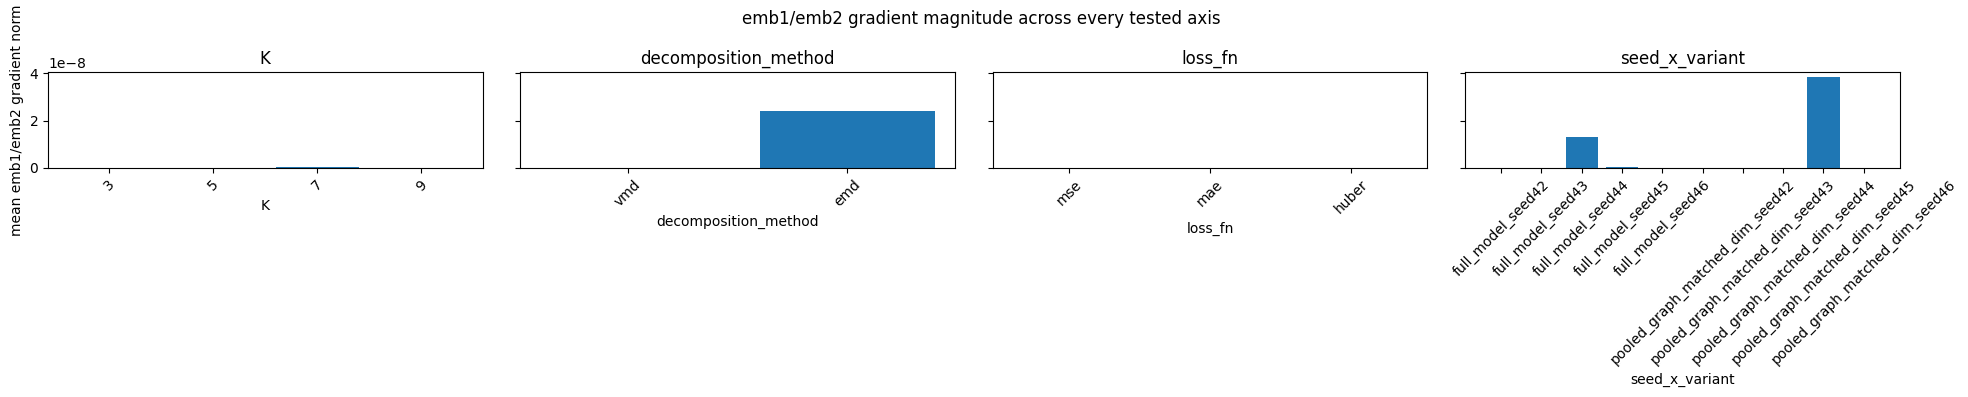

[14:03:36] synced results/robustness/figures -> /content/drive/MyDrive/Copper_Paper1/robustness/figures after figure


In [ ]:
import matplotlib.pyplot as plt

if len(summary_df) == 0:
    print('summary_df is empty -- no completed cells to plot yet, skipping the figure.')
else:
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
    axis_order = ['K', 'decomposition_method', 'loss_fn', 'seed_x_variant']
    for ax, axis_name in zip(axes, axis_order):
        sub = summary_df[summary_df['axis'] == axis_name]
        if len(sub) == 0:
            ax.set_title(f'{axis_name} (no data)')
            continue
        ax.bar(sub['value'].astype(str), sub['emb_grad_norm_mean'])
        ax.set_title(axis_name)
        ax.set_xlabel(axis_name)
        ax.tick_params(axis='x', rotation=45)
    axes[0].set_ylabel('mean emb1/emb2 gradient norm')
    fig.suptitle('emb1/emb2 gradient magnitude across every tested axis')
    fig.tight_layout()
    os.makedirs('results/robustness/figures', exist_ok=True)
    fig.savefig('results/robustness/figures/collapse_invariance_grad_norms.png', dpi=150)
    plt.show()
    sync_to_drive('results/robustness/figures', note='after figure')


## Section 9: Package Results for Download

Zips everything needed to reproduce every number and figure above without
retraining (jsonl grids, checkpoints, the aggregation CSV, the figure), then
copies the zip to Drive as well so it survives even if not downloaded
immediately -- same final-packaging pattern as CuBench's notebook.


In [ ]:
import shutil

if not os.path.isdir('results/robustness'):
    raise SystemExit('results/robustness/ does not exist -- no experiment has produced output yet, nothing to package.')

shutil.make_archive('/content/robustness_results', 'zip', 'results/robustness')
print('Packaged: /content/robustness_results.zip')
print('Size (MB):', os.path.getsize('/content/robustness_results.zip') / 1e6)

# Drive copy FIRST -- this is the copy that actually matters and the one that
# survives an unattended run.
shutil.copy2('/content/robustness_results.zip', os.path.join(DRIVE_ROOT, 'robustness_results.zip'))
print('Also copied to Drive:', os.path.join(DRIVE_ROOT, 'robustness_results.zip'))

# The browser download is best-effort: files.download() raises if the notebook's
# browser tab is closed or the session has been idle-disconnected, which is the
# NORMAL state at the end of an unattended multi-hour run. Never let that turn a
# fully successful run into a red failed cell -- the zip is already on Drive.
try:
    from google.colab import files
    files.download('/content/robustness_results.zip')
except Exception as e:
    print(f'Browser download unavailable ({type(e).__name__}: {e}) -- expected if '
          f'you were not watching the tab. Grab the zip from Drive instead: '
          f'{os.path.join(DRIVE_ROOT, "robustness_results.zip")}')


Packaged: /content/robustness_results.zip
Size (MB): 87.313803
Also copied to Drive: /content/drive/MyDrive/Copper_Paper1/robustness_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Section 10 (Addendum -- separate from this notebook's collapse-diagnostic scope): Ablation Study & Graph-Fix Re-run with `min_epochs` Floor Fix

This section is unrelated to the K / decomposition / loss / seed
collapse-invariance question Sections 1-9 investigate (see item 5 in the
"Done" cell below -- this notebook was designed to not touch the main
pipeline's `results/`). It exists to close out a separate, previously
diagnosed bug that confounds two *other* main-pipeline comparisons in
`main.tex`, not the collapse-invariance study above.

**The bug (already fixed in `src/utils.py` / `src/trainer.py`, see STATUS.md):**
`EarlyStopper` had no floor on how early it could accept a "best" checkpoint,
so both `run_ablation_studies` (`src/trainer.py`) and the graph-fix
experiment's `full_model_graphfix` / `pooled_graph_graphfix` training
(originally run in
`notebooks/archive_paper1_vmd_mfgnn/vmd_mfgnn_v2_colab.ipynb` and
`..._graphfix.ipynb`, both *before* this fix existed) could land their "best"
checkpoint at epoch 0 -- before any real learning -- confounding the
ablation/graph-fix comparisons with training-length artifacts rather than
real architecture differences. `EarlyStopper(min_epochs=...)` and the
`best_eligible_val_mse`-gated checkpoint selection are already in place;
nothing had actually set `min_epochs` to a nonzero value yet. That's what the
two cells below do.

**`min_epochs=10`:** comfortably below `patience=20` (so it can only change
*which* epoch's weights get checkpointed as "best" -- it can never lengthen
training, since `should_stop()` couldn't fire before epoch 20 regardless of
this floor), and comfortably below the ~21-71 epochs the real,
non-degenerate graph-fix variants trained for in the original archived run
(`full_model_graphfix`: 21 epochs; `pooled_graph_graphfix`: 71 epochs) -- so
it floors out the epoch-0 degenerate case without over-constraining a variant
that genuinely converges fast.

Both cells reuse `base_data` (K=5, the default/main-pipeline decomposition,
built in Section 2) and `config` (`configs/default.yaml`), NOT the
K-sweep/robustness data structures Sections 3-9 build -- this is the
ablation/graph-fix protocol's own convention, independent of the
collapse-invariance grid above. The graph-fix cell reuses the same
HPO-tuned hyperparameters (`results/archive_paper1/hpo_best_params.json`) and
the same `no_decay_graph_embeddings` / `normalize_graph_embeddings` fixes as
the original archived graph-fix run.


In [9]:
import copy, json, os, shutil, time
from src.trainer import run_ablation_studies

ABLATION_DIR = 'results/ablation_minepochs_fix'
os.makedirs(ABLATION_DIR, exist_ok=True)

ablation_config = copy.deepcopy(config)
ablation_config['training']['min_epochs'] = 10  # see Section 10 markdown above for rationale

t0 = time.time()
ablation_results_fixed = run_ablation_studies(ablation_config, base_data)
print(f'Ablation studies (min_epochs=10) done in {time.time() - t0:.1f}s')
for key, res in ablation_results_fixed.items():
    print(f"{key:35s} final_epoch={res.get('final_epoch')} avg_mse={res.get('avg_mse')}")

with open(os.path.join(ABLATION_DIR, 'ablation_results_minepochs_fix.json'), 'w') as f:
    json.dump(ablation_results_fixed, f, indent=2, default=str)

# Same Drive-sync convention as Sections 3-9 (sync_to_drive computes
# os.path.relpath(local_dir, 'results') internally, so each of these lands
# under DRIVE_ROOT/<same relative path>).
sync_to_drive(ABLATION_DIR, note='ablation re-run, min_epochs=10 fix')
sync_to_drive('results/ablation_predictions', note='ablation per-sample predictions, min_epochs=10 fix')
sync_to_drive('results/checkpoints', note='ablation checkpoints, min_epochs=10 fix')


Ablation studies (min_epochs=10) done in 10509.8s
full_model                          final_epoch=43 avg_mse=0.002829044904501643
no_vmd_raw_price_matched_dim        final_epoch=21 avg_mse=0.0030309494977700524
no_vmd_raw_price_matched_params     final_epoch=39 avg_mse=0.0028767530093318783
pooled_graph_matched_dim            final_epoch=25 avg_mse=0.0032292816613335162
pooled_graph_matched_params         final_epoch=20 avg_mse=0.002710393884626683
correlation_graph                   final_epoch=34 avg_mse=0.0026679226648411714
[08:12:33] synced results/ablation_minepochs_fix -> /content/drive/MyDrive/Copper_Paper1/ablation_minepochs_fix ablation re-run, min_epochs=10 fix
[08:12:34] synced results/ablation_predictions -> /content/drive/MyDrive/Copper_Paper1/ablation_predictions ablation per-sample predictions, min_epochs=10 fix
[08:12:36] synced results/checkpoints -> /content/drive/MyDrive/Copper_Paper1/checkpoints ablation checkpoints, min_epochs=10 fix


In [10]:
import copy, json, os, time
import numpy as np
from src.trainer import VMDMFGNNTrainer, _find_matched_hidden_dim
from src.models.vmd_mfgnn import VMDMFGNN
from src.models.pooled_graph_mfgnn import PooledGraphMFGNN, count_parameters
from src.utils import set_seed

GRAPHFIX_DIR = 'results/graphfix_minepochs_fix'
os.makedirs(os.path.join(GRAPHFIX_DIR, 'predictions'), exist_ok=True)
os.makedirs(os.path.join(GRAPHFIX_DIR, 'checkpoints'), exist_ok=True)

# Same tuned-hyperparameter convention as Sections 3-7 (exp._load_tuned_hyperparams /
# exp._build_tuned_config), plus the two graph-fix flags and the min_epochs floor.
best_params = exp._load_tuned_hyperparams(
    'results/archive_paper1/hpo_best_params.json',
    fallback_model_cfg=config['model'], fallback_lr=config['training']['learning_rate'])
graphfix_config = exp._build_tuned_config(config, best_params)
graphfix_config['model']['normalize_graph_embeddings'] = True    # fix #2: isotropic-norm-collapse fix
graphfix_config['training']['no_decay_graph_embeddings'] = True  # fix #1: exclude emb1/emb2 from weight decay
graphfix_config['training']['min_epochs'] = 10                   # fix #3 (this task): non-degenerate checkpoint floor
mc = graphfix_config['model']
seed = graphfix_config['training']['seed']


def _save_predictions(name, model, trainer):
    preds = trainer.predict(base_data['test_loader'])
    ys = []
    for _, y in base_data['test_loader']:
        ys.append(y.numpy() if hasattr(y, 'numpy') else y)
    true = np.concatenate(ys, axis=0)
    for i, h in enumerate(model.horizons):
        np.save(os.path.join(GRAPHFIX_DIR, 'predictions', f'{name}_{h}.npy'), preds[str(h)])
        np.save(os.path.join(GRAPHFIX_DIR, 'predictions', f'{name}_{h}_true.npy'), true[:, i])


# STEP 1: full_model_graphfix -- VMDMFGNN, per-band learned graphs, both fixes ON.
set_seed(seed)
full_model_graphfix = VMDMFGNN(
    num_vars=base_data['num_vars'], num_modes=base_data['num_modes'],
    hidden_dim=mc['hidden_dim'], num_heads=mc['num_heads'],
    num_gnn_layers=mc['num_gnn_layers'], temporal_layers=mc['temporal_layers'],
    dropout=mc['dropout'], horizons=base_data['horizons'], graph_type='learned',
    normalize_graph_embeddings=True,
)
full_params_graphfix = count_parameters(full_model_graphfix)
print(f'full_model_graphfix param count: {full_params_graphfix:,} (hidden_dim={mc["hidden_dim"]})')

trainer_full = VMDMFGNNTrainer(full_model_graphfix, graphfix_config)
t0 = time.time()
trainer_full.fit(base_data['train_loader'], base_data['val_loader'],
                  checkpoint_path=os.path.join(GRAPHFIX_DIR, 'checkpoints', 'full_model_graphfix.pt'))
print(f'full_model_graphfix training done in {time.time() - t0:.1f}s, final_epoch={trainer_full.final_epoch}')
test_results_full_graphfix = trainer_full.evaluate(base_data['test_loader'])
test_results_full_graphfix['name'] = 'full_model_graphfix'
test_results_full_graphfix['final_epoch'] = trainer_full.final_epoch
print('full_model_graphfix test results:', test_results_full_graphfix)
_save_predictions('full_model_graphfix', full_model_graphfix, trainer_full)

# STEP 2: pooled_graph_graphfix -- PooledGraphMFGNN, capacity-matched to
# full_model_graphfix (same _find_matched_hidden_dim helper the ablation
# study uses), both fixes ON.
def build_pooled_graphfix(h):
    return PooledGraphMFGNN(
        num_vars=base_data['num_vars'], num_modes=base_data['num_modes'],
        hidden_dim=h, num_heads=mc['num_heads'], num_gnn_layers=mc['num_gnn_layers'],
        temporal_layers=mc['temporal_layers'], dropout=mc['dropout'],
        horizons=base_data['horizons'], graph_type='learned',
        normalize_graph_embeddings=True,
    )


matched_h, matched_c = _find_matched_hidden_dim(build_pooled_graphfix, full_params_graphfix, mc['num_heads'])
print(f'matched pooled_graph_graphfix to hidden_dim={matched_h}, {matched_c:,} params '
      f"vs full_model_graphfix's {full_params_graphfix:,} "
      f'({(matched_c - full_params_graphfix) / full_params_graphfix * 100:+.1f}%)')

set_seed(seed)
pooled_graph_graphfix = build_pooled_graphfix(matched_h)
trainer_pooled = VMDMFGNNTrainer(pooled_graph_graphfix, graphfix_config)
t0 = time.time()
trainer_pooled.fit(base_data['train_loader'], base_data['val_loader'],
                    checkpoint_path=os.path.join(GRAPHFIX_DIR, 'checkpoints', 'pooled_graph_graphfix.pt'))
print(f'pooled_graph_graphfix training done in {time.time() - t0:.1f}s, final_epoch={trainer_pooled.final_epoch}')
test_results_pooled_graphfix = trainer_pooled.evaluate(base_data['test_loader'])
test_results_pooled_graphfix['name'] = 'pooled_graph_graphfix'
test_results_pooled_graphfix['final_epoch'] = trainer_pooled.final_epoch
print('pooled_graph_graphfix test results:', test_results_pooled_graphfix)
_save_predictions('pooled_graph_graphfix', pooled_graph_graphfix, trainer_pooled)

with open(os.path.join(GRAPHFIX_DIR, 'graphfix_minepochs_fix_metrics.json'), 'w') as f:
    json.dump({'full_model_graphfix': test_results_full_graphfix,
               'pooled_graph_graphfix': test_results_pooled_graphfix}, f, indent=2, default=str)

sync_to_drive(GRAPHFIX_DIR, note='graphfix re-run, min_epochs=10 fix')


full_model_graphfix param count: 1,461,124 (hidden_dim=128)
full_model_graphfix training done in 3396.7s, final_epoch=57
full_model_graphfix test results: {'h1': {'rmse': np.float64(0.018067532259415438), 'mae': 0.012309947982430458, 'mape': np.float32(129.57031), 'r2': -0.023712158203125, 'da': np.float64(51.32113821138211)}, 'h5': {'rmse': np.float64(0.03953076815829809), 'mae': 0.02894062176346779, 'mape': np.float32(174.293), 'r2': 0.017660081386566162, 'da': np.float64(50.50813008130082)}, 'h10': {'rmse': np.float64(0.05438409667546376), 'mae': 0.04132022708654404, 'mape': np.float32(227.9856), 'r2': 0.027859389781951904, 'da': np.float64(49.69512195121951)}, 'h22': {'rmse': np.float64(0.07609858410380582), 'mae': 0.058806076645851135, 'mape': np.float32(228.11449), 'r2': -0.008885383605957031, 'da': np.float64(48.170731707317074)}, 'avg_mse': np.float64(0.002659435456735082), 'name': 'full_model_graphfix', 'final_epoch': 57}
matched pooled_graph_graphfix to hidden_dim=276, 1,456,

### Section 10b: Embedding/Adjacency Diagnostic on the Real (Non-Degenerate) Graph-Fix Checkpoints

The graph-fix checkpoints saved just above (`full_model_graphfix`, epoch 57;
`pooled_graph_graphfix`, epoch 27) are the first genuinely-trained ones --
the earlier report in `main.tex` Section V-E ("the fixed mechanism still
learns nothing") was based on an older checkpoint that turned out to be
near-epoch-0 (undertrained), which confounds "didn't learn" with "barely
trained." This cell re-runs the exact same diagnostic
(`src/diagnostics.py::run_full_diagnostic`) used everywhere else in this
paper, on the new checkpoints, so that finding can be verified or corrected
against real training.


In [10]:
import torch
from src.models.vmd_mfgnn import VMDMFGNN
from src.models.pooled_graph_mfgnn import PooledGraphMFGNN
from src.diagnostics import run_full_diagnostic
from src.utils import set_seed, get_device
from src.trainer import _find_matched_hidden_dim
from src.models.pooled_graph_mfgnn import count_parameters as _cp

restore_from_drive_if_present('results/graphfix_minepochs_fix/checkpoints')
device = get_device()
best_params = exp._load_tuned_hyperparams(
    'results/archive_paper1/hpo_best_params.json',
    fallback_model_cfg=config['model'], fallback_lr=config['training']['learning_rate'])
graphfix_config = exp._build_tuned_config(config, best_params)
mc = graphfix_config['model']
seed = graphfix_config['training']['seed']

# Recompute matched_h fresh (don't rely on cell 46's leftover kernel state --
# this cell must work even after a runtime restart).
def _build_pooled_for_match(h):
    return PooledGraphMFGNN(
        num_vars=base_data['num_vars'], num_modes=base_data['num_modes'],
        hidden_dim=h, num_heads=mc['num_heads'], num_gnn_layers=mc['num_gnn_layers'],
        temporal_layers=mc['temporal_layers'], dropout=mc['dropout'],
        horizons=base_data['horizons'], graph_type='learned',
        normalize_graph_embeddings=True)

_full_ref = VMDMFGNN(
    num_vars=base_data['num_vars'], num_modes=base_data['num_modes'],
    hidden_dim=mc['hidden_dim'], num_heads=mc['num_heads'],
    num_gnn_layers=mc['num_gnn_layers'], temporal_layers=mc['temporal_layers'],
    dropout=mc['dropout'], horizons=base_data['horizons'], graph_type='learned',
    normalize_graph_embeddings=True)
_full_params_ref = _cp(_full_ref)
matched_h, _ = _find_matched_hidden_dim(_build_pooled_for_match, _full_params_ref, mc['num_heads'])
print(f'recomputed matched_h={matched_h} (for pooled_graph_graphfix)')

for name, ModelClass, extra_kwargs, hidden_dim in [
    ('full_model_graphfix', VMDMFGNN,
     dict(num_vars=base_data['num_vars'], num_modes=base_data['num_modes']), mc['hidden_dim']),
    ('pooled_graph_graphfix', PooledGraphMFGNN,
     dict(num_vars=base_data['num_vars'], num_modes=base_data['num_modes']), matched_h),
]:
    trained = ModelClass(
        hidden_dim=hidden_dim, num_heads=mc['num_heads'],
        num_gnn_layers=mc['num_gnn_layers'], temporal_layers=mc['temporal_layers'],
        dropout=mc['dropout'], horizons=base_data['horizons'], graph_type='learned',
        normalize_graph_embeddings=True, **extra_kwargs)
    state = torch.load(f'results/graphfix_minepochs_fix/checkpoints/{name}.pt', map_location=device)
    trained.load_state_dict(state['state_dict'] if 'state_dict' in state else state)
    trained.to(device)

    set_seed(seed)
    fresh = ModelClass(
        hidden_dim=hidden_dim, num_heads=mc['num_heads'],
        num_gnn_layers=mc['num_gnn_layers'], temporal_layers=mc['temporal_layers'],
        dropout=mc['dropout'], horizons=base_data['horizons'], graph_type='learned',
        normalize_graph_embeddings=True, **extra_kwargs).to(device)

    diag = run_full_diagnostic(trained, fresh, base_data['test_loader'], device,
                                num_vars=base_data['num_vars'])
    print(f'=== {name} (checkpoint epoch {state.get("epoch", "?")}) ===')
    print(diag)
    print()


Restored /content/drive/MyDrive/Copper_Paper1/graphfix_minepochs_fix/checkpoints -> results/graphfix_minepochs_fix/checkpoints
recomputed matched_h=276 (for pooled_graph_graphfix)
=== full_model_graphfix (checkpoint epoch 57) ===
{'adjacency_state': {'bands': [{'band': 0, 'emb1_rms': 0.30252963304519653, 'emb2_rms': 0.27460283041000366, 'rms_ratio': 1.000229572712652, 'softmax_std': 0.017199566587805748, 'frac_near_uniform': 0.15625, 'collapsed': False}, {'band': 1, 'emb1_rms': 0.2795133888721466, 'emb2_rms': 0.27467697858810425, 'rms_ratio': 0.9604685744545076, 'softmax_std': 0.017917005345225334, 'frac_near_uniform': 0.0, 'collapsed': False}, {'band': 2, 'emb1_rms': 0.2922429144382477, 'emb2_rms': 0.27335983514785767, 'rms_ratio': 0.9802473996292987, 'softmax_std': 0.012971043586730957, 'frac_near_uniform': 0.125, 'collapsed': False}, {'band': 3, 'emb1_rms': 0.29266560077667236, 'emb2_rms': 0.2698376476764679, 'rms_ratio': 0.9748756472324789, 'softmax_std': 0.015627872198820114, 'fra

### Section 10c: Sign-Concentration, Base-Rate-Identity, and DM-Significance Sweep

Runs entirely on local numpy arrays (no Drive MCP round-trips) -- computes,
for the first time, real per-sample diagnostics for the ablation study
(prediction arrays were never archived before this session's fix) and the
graph-fix experiment's freshly-trained (non-degenerate) checkpoints:
1. Sign concentration + exact base-rate-identity match for all 24 ablation
   cells -- upgrades the paper's 6 'candidate' artifact flags to
   CONFIRMED/NOT-CONFIRMED with real evidence, and catches any others.
2. A real Diebold-Mariano test between `full_model` and
   `pooled_graph_matched_params` (the paper's central RQ1 comparison),
   which has never had a significance test before.
3. The same sign-concentration/dispersion check on the graph-fix models,
   to check whether `pooled_graph_graphfix` is still degenerate now that
   it's genuinely trained (27 epochs) rather than the near-epoch-0
   checkpoint the paper's current Section V-E text is based on.


In [11]:
import numpy as np
from src.utils import diebold_mariano_test

restore_from_drive_if_present('results/ablation_predictions')
restore_from_drive_if_present('results/graphfix_minepochs_fix/predictions')

CLASS_FREQ = {  # (up_pct, down_pct) per horizon, from main.tex's own computation
    1: (51.016, 48.374), 5: (53.049, 46.951), 10: (55.386, 44.207), 22: (55.285, 44.715),
}

def analyze_cell(pred_path, true_path, horizon):
    pred = np.load(pred_path).flatten()
    true = np.load(true_path).flatten()
    pos_frac = float(np.mean(pred > 0))
    neg_frac = float(np.mean(pred < 0))
    maj_frac = max(pos_frac, neg_frac)
    maj_sign = 'pos' if pos_frac >= neg_frac else 'neg'
    da = float(np.mean(np.sign(true) == np.sign(pred)) * 100)
    up_freq, down_freq = CLASS_FREQ[horizon]
    matches_up = abs(da - up_freq) < 0.01
    matches_down = abs(da - down_freq) < 0.01
    dispersion = float(np.std(pred) / np.std(true))
    return dict(da=da, maj_sign=maj_sign, maj_frac=maj_frac * 100,
                matches_up=matches_up, matches_down=matches_down, dispersion=dispersion,
                err=(true - pred))

print('=' * 100)
print('ABLATION STUDY -- 24-cell sign-concentration / base-rate-identity / dispersion sweep')
print('=' * 100)
ablation_variants = ['full_model', 'no_vmd_raw_price_matched_dim', 'no_vmd_raw_price_matched_params',
                      'pooled_graph_matched_dim', 'pooled_graph_matched_params', 'correlation_graph']
horizons = [1, 5, 10, 22]
ablation_cells = {}
for v in ablation_variants:
    for h in horizons:
        pred_path = f'results/ablation_predictions/{v}_{h}.npy'
        true_path = f'results/ablation_predictions/{v}_{h}_true.npy'
        r = analyze_cell(pred_path, true_path, h)
        ablation_cells[(v, h)] = r
        flag = ''
        if r['maj_frac'] >= 90 and (r['matches_up'] or r['matches_down']):
            flag = '  <== CONFIRMED base-rate artifact (>=90% sign-concentrated AND exact class-freq match)'
        elif r['matches_up'] or r['matches_down']:
            flag = '  <== exact class-freq match but NOT >=90% sign-concentrated (coincidental, like Transformer h22)'
        elif r['maj_frac'] >= 90:
            flag = '  <== >=90% sign-concentrated but no exact class-freq match (soft flag only)'
        print(f"{v:32s} h={h:2d}  DA={r['da']:7.3f}  maj={r['maj_sign']}({r['maj_frac']:5.1f}%)  "
              f"disp={r['dispersion']:.3f}{flag}")

print()
print('=' * 100)
print('ABLATION SIGNIFICANCE -- Diebold-Mariano, full_model vs pooled_graph_matched_params (RQ1)')
print('=' * 100)
for h in horizons:
    e1 = ablation_cells[('full_model', h)]['err']
    e2 = ablation_cells[('pooled_graph_matched_params', h)]['err']
    res = diebold_mariano_test(e1, e2, horizon=h)
    sig = 'SIGNIFICANT (raw p<0.05)' if res['p_value'] < 0.05 else 'not significant'
    winner = 'full_model better' if res['dm_stat'] < 0 else 'pooled_graph_matched_params better'
    print(f"h={h:2d}  DM={res['dm_stat']:+.4f}  p={res['p_value']:.4f}  {sig}  ({winner})")

print()
print('=' * 100)
print('GRAPH-FIX -- 8-cell sign-concentration / dispersion check (real 57/27-epoch checkpoints)')
print('=' * 100)
for v in ['full_model_graphfix', 'pooled_graph_graphfix']:
    for h in horizons:
        pred_path = f'results/graphfix_minepochs_fix/predictions/{v}_{h}.npy'
        true_path = f'results/graphfix_minepochs_fix/predictions/{v}_{h}_true.npy'
        r = analyze_cell(pred_path, true_path, h)
        flag = ''
        if r['maj_frac'] >= 90 and (r['matches_up'] or r['matches_down']):
            flag = '  <== CONFIRMED base-rate artifact'
        elif r['matches_up'] or r['matches_down']:
            flag = '  <== exact class-freq match but NOT >=90% sign-concentrated'
        elif r['maj_frac'] >= 90:
            flag = '  <== >=90% sign-concentrated, no exact match'
        print(f"{v:24s} h={h:2d}  DA={r['da']:7.3f}  maj={r['maj_sign']}({r['maj_frac']:5.1f}%)  "
              f"disp={r['dispersion']:.3f}{flag}")


Restored /content/drive/MyDrive/Copper_Paper1/ablation_predictions -> results/ablation_predictions
Restored /content/drive/MyDrive/Copper_Paper1/graphfix_minepochs_fix/predictions -> results/graphfix_minepochs_fix/predictions
ABLATION STUDY -- 24-cell sign-concentration / base-rate-identity / dispersion sweep
full_model                       h= 1  DA= 48.577  maj=neg( 84.9%)  disp=0.173
full_model                       h= 5  DA= 49.695  maj=neg( 75.5%)  disp=0.252
full_model                       h=10  DA= 46.545  maj=neg( 90.1%)  disp=0.146  <== >=90% sign-concentrated but no exact class-freq match (soft flag only)
full_model                       h=22  DA= 48.171  maj=neg( 68.3%)  disp=0.271
no_vmd_raw_price_matched_dim     h= 1  DA= 50.915  maj=pos( 62.1%)  disp=0.023
no_vmd_raw_price_matched_dim     h= 5  DA= 49.898  maj=neg( 93.2%)  disp=0.155  <== >=90% sign-concentrated but no exact class-freq match (soft flag only)
no_vmd_raw_price_matched_dim     h=10  DA= 44.207  maj=neg(100.

### Section 10d: Is the Zero Embedding Gradient Structural (present from
init) or Learned (develops during training)?

Section 10b found `emb_grad_norm_mean` exactly `0.0` for BOTH trained
graph-fix checkpoints (57 and 27 real epochs) -- not just small, exactly
zero across all 5 measured batches. This cell checks the same statistic on
a FRESH, never-trained model with the same `normalize_graph_embeddings=True`
fix, and a fresh model WITHOUT the fix for contrast, to determine whether
this is a structural property of the fix itself (present from step 0 --
meaning the fix may block the embeddings from ever receiving a gradient at
all, which would be a more serious finding than "gradient too weak") or
something that only emerges after training.


In [ ]:
import torch
from src.diagnostics import gradient_magnitude_diagnostic
from src.models.vmd_mfgnn import VMDMFGNN
from src.models.pooled_graph_mfgnn import PooledGraphMFGNN
from src.utils import set_seed, get_device

# Section 10b found emb_grad_norm_mean EXACTLY 0.0 for both graphfix
# checkpoints, even after 57/27 real training epochs -- this cell checks
# whether that's true from initialization too (a structural property of the
# normalize_graph_embeddings=True path), or only develops during training,
# by running the identical gradient check on FRESH, never-trained models with
# the same fix flags.

device = get_device()
best_params = exp._load_tuned_hyperparams(
    'results/archive_paper1/hpo_best_params.json',
    fallback_model_cfg=config['model'], fallback_lr=config['training']['learning_rate'])
graphfix_config = exp._build_tuned_config(config, best_params)
mc = graphfix_config['model']
seed = graphfix_config['training']['seed']

set_seed(seed)
fresh_full = VMDMFGNN(
    num_vars=base_data['num_vars'], num_modes=base_data['num_modes'],
    hidden_dim=mc['hidden_dim'], num_heads=mc['num_heads'],
    num_gnn_layers=mc['num_gnn_layers'], temporal_layers=mc['temporal_layers'],
    dropout=mc['dropout'], horizons=base_data['horizons'], graph_type='learned',
    normalize_graph_embeddings=True).to(device)
print('=== fresh_full (untrained, normalize_graph_embeddings=True) ===')
print(gradient_magnitude_diagnostic(fresh_full, base_data['test_loader'], device,
                                     num_batches=5))

# Also check the SAME fresh architecture WITHOUT the fix, for contrast --
# this is what the original (pre-fix) collapse diagnosis measured as "weak
# but nonzero" (~1e-5/element). If that's still nonzero here, the zero we
# see with the fix ON is specific to normalize_graph_embeddings, not a
# general property of an untrained model.
set_seed(seed)
fresh_full_nofix = VMDMFGNN(
    num_vars=base_data['num_vars'], num_modes=base_data['num_modes'],
    hidden_dim=mc['hidden_dim'], num_heads=mc['num_heads'],
    num_gnn_layers=mc['num_gnn_layers'], temporal_layers=mc['temporal_layers'],
    dropout=mc['dropout'], horizons=base_data['horizons'], graph_type='learned',
    normalize_graph_embeddings=False).to(device)
print('=== fresh_full_nofix (untrained, normalize_graph_embeddings=False) ===')
print(gradient_magnitude_diagnostic(fresh_full_nofix, base_data['test_loader'], device,
                                     num_batches=5))


---
### Done

Check, in order:
1. Section 8's headline verdict (INVARIANT / MIXED / RESOLVED) -- this is
   the answer to the question this notebook exists to ask.
2. `results/robustness/collapse_invariance_summary.csv` and
   `results/robustness/figures/collapse_invariance_grad_norms.png` for the
   full per-cell detail.
3. `results/robustness/wider_hpo/hpo_wider_best_params.json` +
   `hpo_wider_trials.csv` for whether a wider search found a meaningfully
   different/better configuration than the original 10-trial HPO.
4. `results/robustness/multiseed/multiseed_results.jsonl` (raw per-seed
   metrics) if you want to re-derive the significance test independently of
   this notebook's own computation.
5. None of this touches or needs to be reconciled with the main pipeline's
   `results/` -- entirely separate, as documented in the overview cell.
